# VQCFD Results Analysis

The reusable logic lives in `analysis.py`. This notebook only contains run selections and plotting options.


In [56]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import analysis as an

an.configure_plots()
RESULTS_ROOT = an.RESULTS_ROOT
RESULTS_ROOT


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


PosixPath('/Users/joel/Documents/MA/Code/VQCFD_quimb/results')

## Discover saved runs


In [57]:
# Each filter accepts one value, a list of values, or None for every value.
NS = [7,8,9]                # e.g. 3 or [2, 3, 4]
LS = None                 # e.g. 2 or [1, 2, 3]
CIRCUITS = None           # e.g. "multiscale_tree" or ["default", "uni2"]
INITIAL_STATES = None     # e.g. "sine" or ["sine", "tapered_gaussian"]
MODES = ["gradient"]              # e.g. "noise_free" or ["variance", "gradient"]

runs = an.list_runs(
    ns=NS,
    ls=LS,
    circuits=CIRCUITS,
    initial_states=INITIAL_STATES,
    modes=MODES,
)
an.print_runs(runs)


 N  L Circuit Initial state     Mode  Parameters  Saved  Variance
 7  1 default          sine gradient          14  False     False
 7  2 default          sine gradient          21  False     False
 7  4 default          sine gradient          35  False     False
 8  1 default          sine gradient          16  False     False
 8  2 default          sine gradient          24  False     False
 8  4 default          sine gradient          40  False     False
 9  1 default          sine gradient          18  False     False
 9  2 default          sine gradient          27  False     False
 9  4 default          sine gradient          45  False     False
count=9


In [16]:
# Optional filters: n=..., l=...
preset_rows = an.list_initial_param_presets(l=3, circuit="multiscale_tree", show_variants=True)


N=2, L=3 | default_len=None
    initial_state=sine | circuit=multiscale_tree | len=9 | mse=4.514059491425526e-16 | tries=20
    initial_state=positive_hump | circuit=multiscale_tree | len=9 | mse=3.240041969452473e-14 | tries=20
    initial_state=positive_periodic_wave | circuit=multiscale_tree | len=9 | mse=5.794195581759437e-13 | tries=20
    initial_state=mixed_sine_modes | circuit=multiscale_tree | len=9 | mse=6.101211895731208e-16 | tries=20
    initial_state=tapered_gaussian | circuit=multiscale_tree | len=9 | mse=2.9556093854172242e-15 | tries=20
    initial_state=tapered_tanh | circuit=multiscale_tree | len=9 | mse=1.2818947528256624e-16 | tries=20
N=3, L=3 | default_len=13 | default_mse=2.7249064307398952e-11
    initial_state=sine | circuit=multiscale_tree | len=13 | mse=0.02769895069454973 | tries=20
    initial_state=positive_hump | circuit=multiscale_tree | len=13 | mse=0.11948638080145609 | tries=20
    initial_state=positive_periodic_wave | circuit=multiscale_tree | len=

## Inspect one run


In [3]:
DIR_LABEL = "N5"
LABEL = "L5"

run = an.load_run(DIR_LABEL, LABEL)
run


RunData(dir_label='N5', label='L5', full_label='N5_L5', results_dir=PosixPath('/Users/joel/Documents/MA/Code/VQCFD_quimb/results/results_N5'), data_dir=PosixPath('/Users/joel/Documents/MA/Code/VQCFD_quimb/results/results_N5/data_L5'), fig_dir=PosixPath('/Users/joel/Documents/MA/Code/VQCFD_quimb/results/results_N5/figures_L5'), manifest={'cobyla_maxiter': 100000, 'cobyla_tol': 1e-05, 'compute_expr_cap': True, 'data_dir': 'results/results_N5/data_L5', 'dir_label': 'N5', 'dt': 0.01, 'expr_bins': 100, 'expr_entcap_samples': 100000, 'fig_dir': 'results/results_N5/figures_L5', 'grad_tol': 0.001, 'init_param_random_center': 2.891592653589793, 'init_param_random_scale': 0.1, 'initial_params': None, 'initial_params_presets_file': 'initial_params_presets.yaml', 'initial_params_variant': None, 'l': 5, 'label': 'L5', 'manifest_path': 'results/results_N5/manifest_N5_L5.yaml', 'max_iter': 100, 'mode': 'noise_free', 'mu': 0.01, 'n': 5, 'n_timesteps': 28, 'n_total': 32, 'optimization_steps': 1000, 'pa

In [4]:
print("manifest path:", run.files["manifest"])
print("values yaml path:", run.files["values_yaml"])
print("values keys:", list(run.values.keys()))
run.values


manifest path: /Users/joel/Documents/MA/Code/VQCFD_quimb/results/results_N5/manifest_N5_L5.yaml
values yaml path: /Users/joel/Documents/MA/Code/VQCFD_quimb/results/results_N5/data_L5/values_N5_L5.yaml
values keys: ['n', 'l', 'shots', 'max_iter', 't_total', 'mu', 'dt', 'plat_tol', 'patience', 'initial_params_source', 'expressibility', 'entangling_capability', 'initial_fit_mse', 'shots_used_per_timestep', 'shots_used_total']


{'n': 5,
 'l': 5,
 'shots': 100,
 'max_iter': 100,
 't_total': 0.29,
 'mu': 0.01,
 'dt': 0.01,
 'plat_tol': 0.00015,
 'patience': 15,
 'initial_params_source': 'preset',
 'expressibility': 0.12782413492695527,
 'entangling_capability': 0.8318029744040429,
 'initial_fit_mse': 1.0888691785137848e-08,
 'shots_used_per_timestep': [0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0],
 'shots_used_total': 0}

In [17]:
costs = run.costs
times = run.times
params = run.params
variance = run.variance

print("costs:", None if costs is None else costs.shape)
print("times:", None if times is None else times.shape)
print("params:", None if params is None else params.shape)
print("variance:", variance)


costs: (28,)
times: (28,)
params: (29, 21)
variance: None


In [18]:
cost_histories = an.load_per_timestep_histories(run, "cost_iter")
param_histories = an.load_per_timestep_histories(run, "params_iter")
print("cost_iter timesteps:", len(cost_histories))
print("params_iter timesteps:", len(param_histories))


cost_iter timesteps: 28
params_iter timesteps: 0


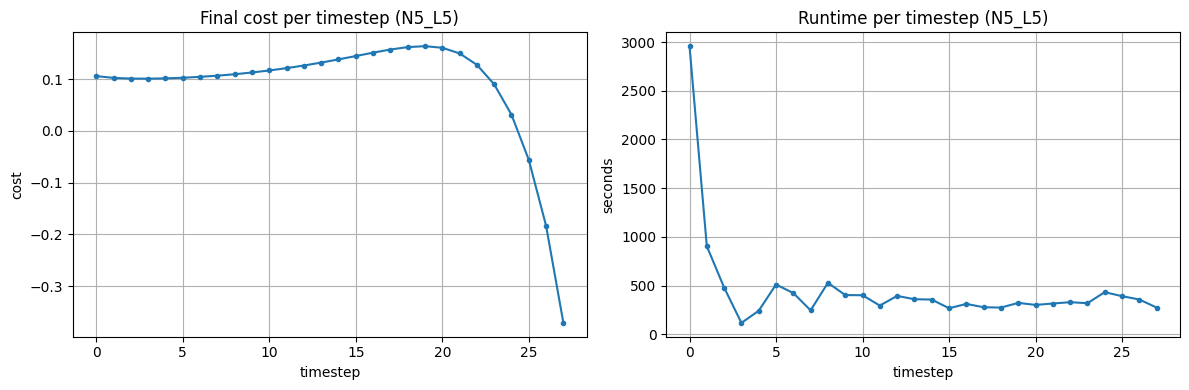

In [5]:
an.plot_costs_and_times(run);


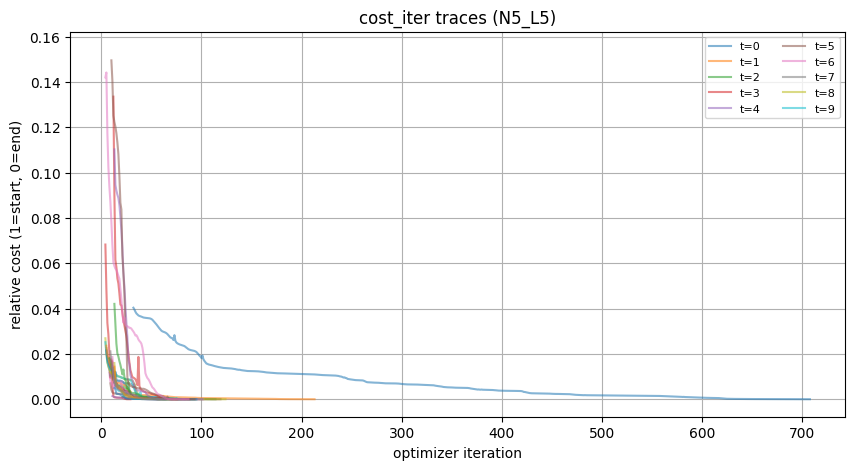

In [6]:
an.plot_cost_histories(
    run,
    normalize=True,
    remove_outliers=True,
    outlier_method="iqr",       # "iqr" or "percentile"
    outlier_factor=3.0,
    outlier_percentiles=(1.0, 99.0),
    show_first_n_labels=10,
);


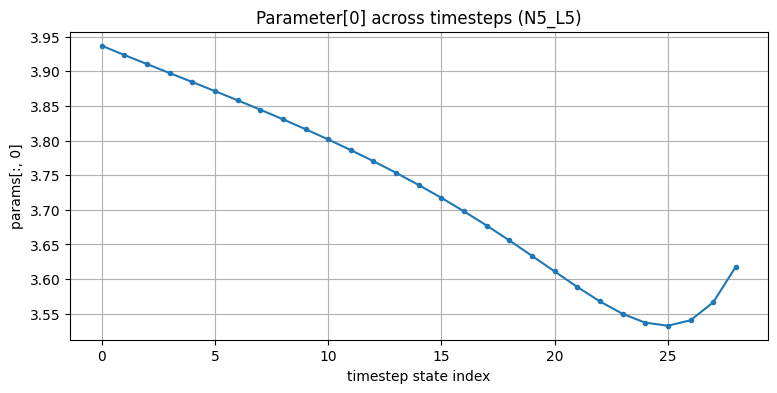

In [7]:
an.plot_parameter_history(run, parameter_index=0);


shots_used_total: 0


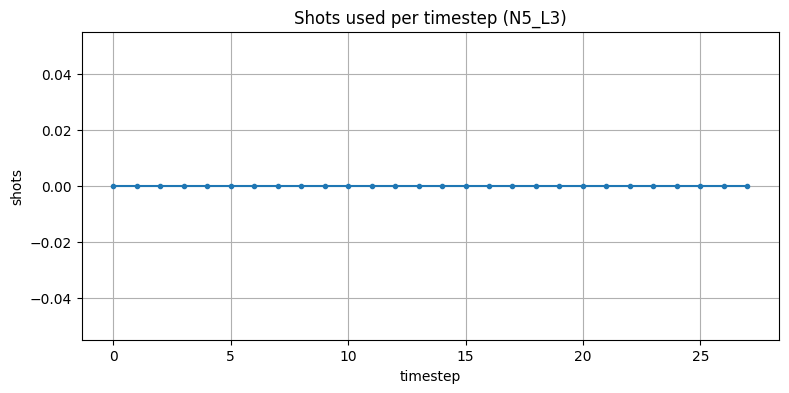

In [ ]:
an.plot_shots(run);

## Classical and quantum fields at one timestep

Use `TIMESTEP = 0` for the initial state, a positive saved-state index, or `-1` for the final state. The plot reports MSE, R², and normalized squared-overlap fidelity.


In [194]:
DIR_LABEL = "N6"
LABEL = "L8"

run = an.load_run(DIR_LABEL, LABEL)
run

RunData(dir_label='N6', label='L8', full_label='N6_L8', results_dir=PosixPath('/Users/joel/Documents/MA/Code/VQCFD_quimb/results/results_N6'), data_dir=PosixPath('/Users/joel/Documents/MA/Code/VQCFD_quimb/results/results_N6/data_L8'), fig_dir=PosixPath('/Users/joel/Documents/MA/Code/VQCFD_quimb/results/results_N6/figures_L8'), manifest={'cobyla_maxiter': 100000, 'cobyla_tol': 1e-05, 'compute_expr_cap': True, 'data_dir': 'results/results_N6/data_L8', 'dir_label': 'N6', 'dt': 0.01, 'expr_bins': 100, 'expr_entcap_samples': 50000, 'fig_dir': 'results/results_N6/figures_L8', 'grad_tol': 0.001, 'init_param_random_center': 2.891592653589793, 'init_param_random_scale': 0.1, 'initial_params': None, 'initial_params_presets_file': 'initial_params_presets.yaml', 'initial_params_variant': None, 'l': 8, 'label': 'L8', 'manifest_path': 'results/results_N6/manifest_N6_L8.yaml', 'max_iter': 100, 'mode': 'noise_free', 'mu': 0.01, 'n': 6, 'n_timesteps': 28, 'n_total': 64, 'optimization_steps': 1000, 'pat

timestep                       2.800000e+01
time                           2.800000e-01
MSE                            3.318663e-08
R2                             9.999999e-01
Fidelity                       9.999999e-01
RelativeL1Error                2.624548e-04
RelativeL2Error                3.236486e-04
RelativeLinfError              8.449692e-04
RelativeDerivativeL2Error      8.584634e-04
RelativeDerivativeLinfError    5.407665e-04
RelativeMassError                       NaN
NormalizedMassDrift            3.225008e+01
dtype: float64

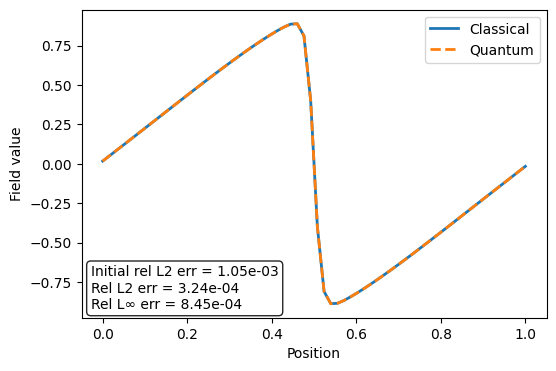

In [195]:
TIMESTEP = -1

timestep_comparison, ax, fig = an.plot_run_timestep_comparison(run, timestep=TIMESTEP)
TIMESTEP_METRICS = [
    "timestep", "time", "MSE", "R2", "Fidelity",
    "RelativeL1Error", "RelativeL2Error", "RelativeLinfError",
    "RelativeDerivativeL2Error", "RelativeDerivativeLinfError",
    "RelativeMassError", "NormalizedMassDrift",
]
pd.Series({key: timestep_comparison[key] for key in TIMESTEP_METRICS})


In [196]:
# fig.savefig(f"figures/single_runs/single_run_{DIR_LABEL}_{LABEL}.pdf", bbox_inches='tight')

## Classical and quantum fields over the whole time evolution

Choose `EVOLUTION_FIELDS = "classical"`, `"quantum"`, or `"both"`. Increase `TIMESTEP_STRIDE` to show fewer saved timesteps.


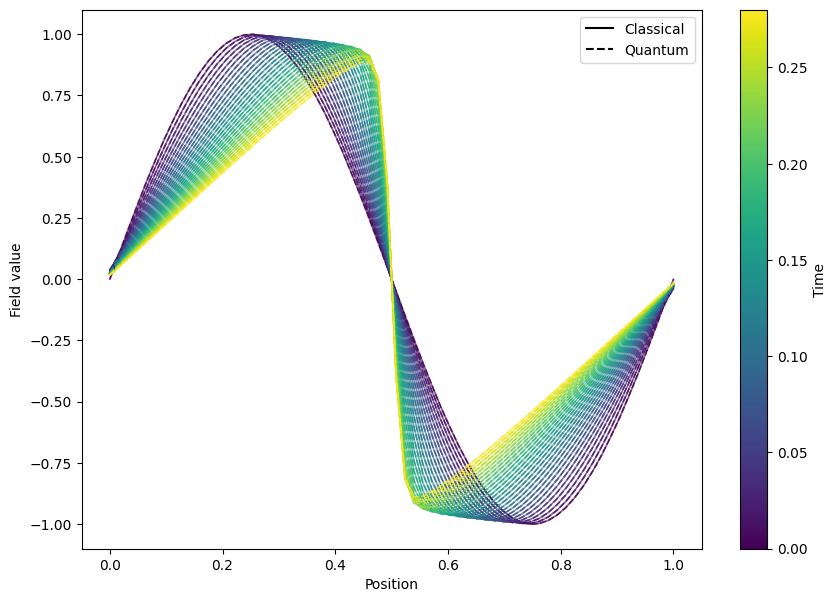

In [197]:
EVOLUTION_FIELDS = "both"       # "classical", "quantum", or "both"
TIMESTEP_STRIDE = 1             # 1 plots every saved timestep

evolution, evolution_ax, evolution_fig = an.plot_run_time_evolution(
    run,
    fields=EVOLUTION_FIELDS,
    timestep_stride=TIMESTEP_STRIDE,
)


In [198]:
evolution_fig.savefig(f"figures/single_runs/single_run_evolution_{DIR_LABEL}_{LABEL}_{EVOLUTION_FIELDS}_{TIMESTEP_STRIDE}.pdf", bbox_inches='tight')

## Expressibility and entangling capability


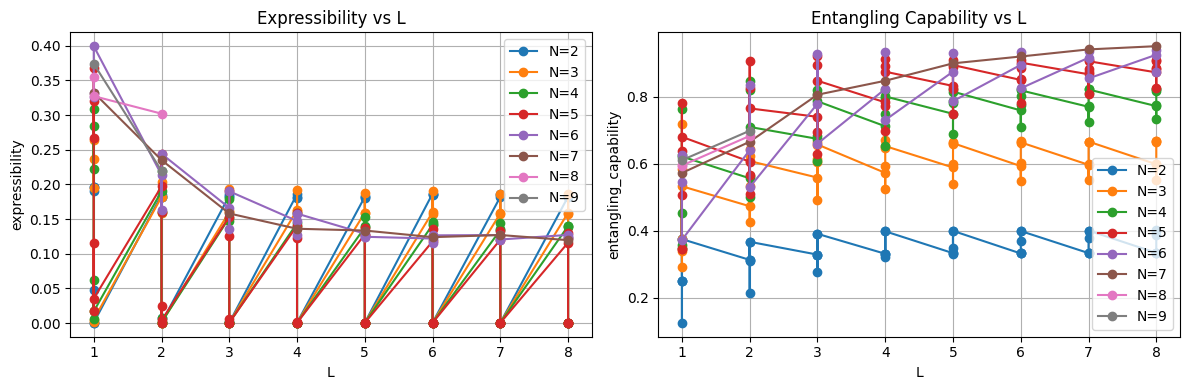

In [9]:
# Add (dir_label, label) pairs here. These select independently saved *_expr results.
# With an empty selection, discover *_expr results and full runs containing either metric.
EXPR_ENTCAP_SELECTION = []

if EXPR_ENTCAP_SELECTION:
    expr_runs = an.load_expr_runs(EXPR_ENTCAP_SELECTION)
else:
    expr_runs = an.discover_expr_runs(include_full_runs=True)

if expr_runs:
    an.plot_expr_entcap_vs_l(expr_runs, n_filter=None)
else:
    print("No selected runs contain expressibility or entangling-capability values.")


## Configurable multi-run comparison table

The table contains N, L, the number of circuit parameters, variance, expressibility, entangling capability, circuit, initial state, final-state R²/fidelity/MSE, relative L1/L2/L∞ field errors, relative L2/L∞ derivative errors, relative final mass error, and normalized quantum mass drift from the initial to final time. Field derivatives use the simulation's periodic centered difference and mass uses $M=\Delta x\sum_i u_i$. Relative mass values are `NaN` when their reference mass is effectively zero. Variance-only runs can be supplied separately and are matched to simulation runs by `(N, L, Circuit)`. Leave `RUN_SELECTION` empty to select every available non-variance run with saved parameters.

Older manifests do not record a circuit name, so they are shown as `default`. Use `CIRCUIT_OVERRIDES` for older runs whose circuit is known from their label or experiment notes.


In [67]:
RUN_SELECTION = [
    # ("N3", "L2"),
    # ("N4", "L3"),
]

# Optional explicit variance selection. Leave empty to use all discovered variance runs.
VARIANCE_SELECTION = []

# Example: {"experiment_uni2_N4L3": "uni2"}
CIRCUIT_OVERRIDES = {}

selected_runs = an.load_runs(RUN_SELECTION) if RUN_SELECTION else an.discover_simulation_runs()
variance_runs = (
    [an.load_variance_run(d, label) for d, label in VARIANCE_SELECTION]
    if VARIANCE_SELECTION
    else an.discover_variance_runs()
)

run_table = an.build_run_table(
    selected_runs,
    variance_runs=variance_runs,
    circuit_overrides=CIRCUIT_OVERRIDES,
)
run_table


/Users/joel/Documents/MA/Code/VQCFD_quimb/analysis.py:657: RuntimeWarning: overflow encountered in multiply
  - (dt / (2 * dx)) * previous * (right - left)
/Users/joel/Documents/MA/Code/VQCFD_quimb/analysis.py:656: RuntimeWarning: invalid value encountered in subtract
  + (mu * dt / dx**2) * (right - 2 * previous + left)
/Users/joel/Documents/MA/Code/VQCFD_quimb/analysis.py:656: RuntimeWarning: invalid value encountered in add
  + (mu * dt / dx**2) * (right - 2 * previous + left)
/Users/joel/Documents/MA/Code/VQCFD_quimb/analysis.py:655: RuntimeWarning: invalid value encountered in add
  previous
/Users/joel/Documents/MA/Code/VQCFD_quimb/analysis.py:657: RuntimeWarning: invalid value encountered in subtract
  - (dt / (2 * dx)) * previous * (right - left)
/Users/joel/Documents/MA/Code/VQCFD_quimb/analysis.py:655: RuntimeWarning: invalid value encountered in subtract
  previous


,Run,N,L,NumberOfParameters,Var,Expressibility,EntanglingCapability,Circuit,InitialState,R2,Fidelity,MSE,RelativeL1Error,RelativeL2Error,RelativeLinfError,RelativeDerivativeL2Error,RelativeDerivativeLinfError,RelativeMassError,NormalizedMassDrift
0,N2_L1,2,1,4,NaN,0.196844,0.250619,default,sine,1.000000,1.0,2.326261e-11,0.000006,0.000006,0.000006,0.000005,0.000007,NaN,85.453496
1,N2_L1_mixed_sine_modes,2,1,4,NaN,NaN,NaN,default,mixed_sine_modes,1.000000,1.0,3.703596e-10,0.000043,0.000040,0.000040,0.000036,0.000040,NaN,10484.173573
2,N2_L1_positive_periodic_wave,2,1,4,NaN,NaN,NaN,default,positive_periodic_wave,1.000000,1.0,8.548699e-09,0.000171,0.000153,0.000116,0.000352,0.000306,0.000043,0.000043
3,N2_L1_tapered_gaussian,2,1,4,NaN,NaN,NaN,default,tapered_gaussian,0.999999,1.0,2.715782e-08,0.000719,0.000643,0.000725,0.000632,0.000631,0.000415,0.000415
4,N2_L2,2,2,6,NaN,0.184564,0.313082,default,sine,1.000000,1.0,1.484466e-09,0.000043,0.000044,0.000059,0.000047,0.000061,NaN,254.837784
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
867,N7_L4,7,4,35,NaN,0.136111,0.847263,default,sine,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,230.052548
868,N7_L5,7,5,42,NaN,0.133545,0.899190,default,sine,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,62175.059472
869,N7_L6,7,6,49,NaN,0.123996,0.919619,default,sine,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,759559.009344
870,N7_L7,7,7,56,NaN,0.127063,0.940744,default,sine,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,117795.567089


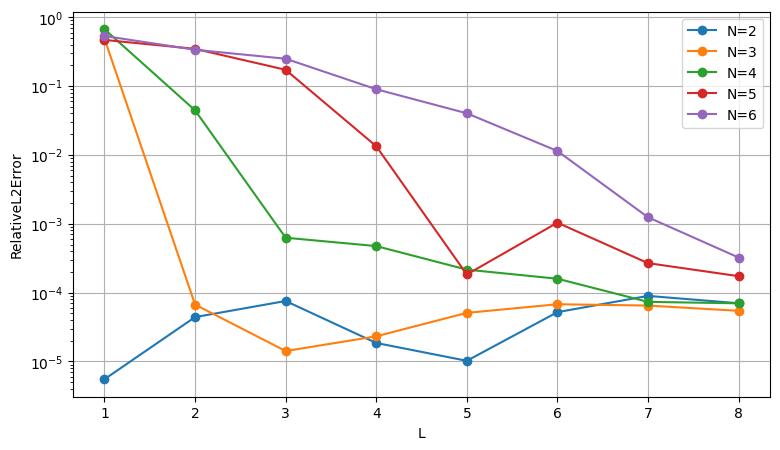

In [157]:
# Any columns in an.RUN_TABLE_COLUMNS can be used for X, Y, or GROUP_BY.
X = "L"
Y = "RelativeL2Error"
GROUP_BY = "N"          # "N", "L", "Circuit", "InitialState", another column, or None

NS = [2,3,4,5,6] # None               # e.g. [3, 4, 5]
LS = [1,2,3,4,5,6,7,8]               # e.g. [1, 2, 3]
CIRCUITS = "default"         # e.g. ["default", "uni2", "brickwork_ring_ry"]
INITIAL_STATES = "sine"   # e.g. ["sine", "tapered_gaussian"]

filtered_table, ax, fig = an.plot_run_table(
    run_table,
    x=X,
    y=Y,
    ns=NS,
    ls=LS,
    circuits=CIRCUITS,
    initial_states=INITIAL_STATES,
    group_by=GROUP_BY,
    kind="line",        # "line" or "scatter"
    log_y=True,
)
# filtered_table


In [ ]:
folder = "this"
name = "that"
fig.savefig(f"figures/{folder}/{name}.pdf", bbox_inches='tight')